In [ ]:
!pip -q install --upgrade xgboost imbalanced-learn shap

In [ ]:
# ============================================================
# BLOCK 1 — SETUP
# ============================================================
# !pip -q install xgboost imbalanced-learn shap --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import warnings, time
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    make_scorer, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# from google.colab import drive
# drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Sreports_dse/notebooks/dse_final_v3.csv"   # <-- adjust to your path
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["trading_code", "date"]).reset_index(drop=True)

print(f"Loaded {len(df):,} rows, {df['trading_code'].nunique()} tickers")
print(df["split"].value_counts())

Loaded 924,946 rows, 321 tickers
split
train    630356
test     294590
Name: count, dtype: int64


In [ ]:
# ============================================================
# BLOCK 2 — FEATURES / TARGET
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]

# XGBoost multi:softprob needs contiguous 0-indexed labels.
# Original classes {0: Normal, 1: High-Vol, 3: Crash} -> remap to {0, 1, 2}.
LABEL_MAP   = {0: 0, 1: 1, 3: 2}
CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}   # remapped space
CRASH_IDX   = 2

df["y"] = df["target_class"].map(LABEL_MAP)
assert df["y"].isnull().sum() == 0, "Unmapped target_class values found"

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

X_train, y_train = train_df[ALL_FEATURES].values, train_df["y"].values.astype(int)
X_test,  y_test  = test_df[ALL_FEATURES].values,  test_df["y"].values.astype(int)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.round(np.bincount(y_train) / len(y_train), 4))
print("Test  class balance:", np.round(np.bincount(y_test) / len(y_test), 4))

Train: (630356, 18)  Test: (294590, 18)
Train class balance: [0.7383 0.206  0.0556]
Test  class balance: [0.7379 0.215  0.0471]


In [ ]:
!pip install arch

In [ ]:
# ============================================================
# BLOCK 3 — BASELINES (Reviewer 4: show ML's added value over trivial rules)
# ============================================================

# (a) Contemporaneous deterministic-rule check: class_same_day is defined
# directly by applying the labeling rule to the same day's raw values, so
# by construction it reproduces the rule with 100% accuracy. This is not
# a competing model — it's a sanity check that the label-generating rule
# itself is internally consistent, satisfying Reviewer 4's request for a
# deterministic-rule benchmark.
print("Contemporaneous rule check: class_same_day is generated directly from the")
print("labeling rule applied to same-day raw values, so it recovers itself with")
print("100% accuracy by construction. Included as a sanity check only, not a")
print("competing model — the real baselines below test t+1 FORECASTING ability.\n")

# (b) Naive persistence: predict tomorrow's class = today's realized class.
#     This is the real "does ML add value" baseline for the FORECASTING task.
persist_pred = test_df["class_same_day"].map(LABEL_MAP).values
persist_acc  = (persist_pred == y_test).mean()
persist_crash_recall = recall_score(y_test == CRASH_IDX, persist_pred == CRASH_IDX)
persist_crash_prec   = precision_score(y_test == CRASH_IDX, persist_pred == CRASH_IDX, zero_division=0)
print(f"[Naive persistence]      acc={persist_acc:.4f}  crash_recall={persist_crash_recall:.4f}  crash_precision={persist_crash_prec:.4f}")

# (c) Lagged-volatility rule: flag high-vol tomorrow if today's intraday
#     volatility exceeds its own train-period 80th percentile; else normal.
#     (Does not attempt to predict crash — crude one-variable heuristic.)
vol_thresh = train_df["intraday_volatility"].quantile(0.80)
lagvol_pred = np.where(test_df["intraday_volatility"] > vol_thresh, 1, 0)
lagvol_acc = (lagvol_pred == y_test).mean()
print(f"[Lagged-volatility rule] acc={lagvol_acc:.4f}  (single-variable heuristic, no crash class)")

# (d) Logistic regression with the same lagged features — a real statistical
#     baseline (not just a rule), multiclass, class-weighted.
logreg = LogisticRegression(max_iter=2000, class_weight="balanced",
                             multi_class="multinomial", random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)
print(f"[Logistic regression]    acc={ (logreg_pred==y_test).mean():.4f}  "
      f"crash_PR-AUC={average_precision_score(y_test==CRASH_IDX, logreg_proba[:,CRASH_IDX]):.4f}")

# (e) GARCH(1,1)-based volatility-regime baseline (optional, simplified).
# A full per-stock GARCH fit across 321 tickers is expensive; this is a
# lightweight pooled-index approximation for benchmarking purposes only —
# flag this simplification explicitly in the paper if you keep it.
try:
    from arch import arch_model
    pooled_returns = train_df.groupby("date")["daily_return"].mean().dropna()
    garch = arch_model(pooled_returns, vol="Garch", p=1, q=1, rescale=False)
    garch_fit = garch.fit(disp="off")
    print("\n[GARCH(1,1) pooled-index] fitted — see garch_fit.summary() for details")
    print(garch_fit.summary().tables[1])
except ImportError:
    print("\n[GARCH] 'arch' package not installed — run `!pip install arch` if you want this baseline")

Contemporaneous rule check: class_same_day is generated directly from the
labeling rule applied to same-day raw values, so it recovers itself with
100% accuracy by construction. Included as a sanity check only, not a
competing model — the real baselines below test t+1 FORECASTING ability.

[Naive persistence]      acc=0.7262  crash_recall=0.1737  crash_precision=0.1736
[Lagged-volatility rule] acc=0.7447  (single-variable heuristic, no crash class)
[Logistic regression]    acc=0.6765  crash_PR-AUC=0.1222

[GARCH(1,1) pooled-index] fitted — see garch_fit.summary() for details
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0184  8.080e-03     -2.279  2.269e-02 [-3.425e-02,-2.575e-03]


In [ ]:
# ============================================================
# BLOCK 4 — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    """
    Expanding-window folds over unique trading dates. Fold k trains on all
    dates before its validation block (expanding), validates on a forward
    contiguous block. An embargo of `embargo_days` is dropped immediately
    before each validation window to reduce leakage from serially-correlated
    rolling-window features/labels near the boundary (Lopez de Prado-style
    purging) — answers Reviewer 4's nested CV / purging-embargo request.
    """
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

unique_train_dates = np.sort(train_df["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_df["date"].values
cv_splits = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} rows) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} rows)")

Fold 1: train 2008-04-03->2010-01-11 (81,245 rows) | val 2010-01-19->2011-11-02 (90,671 rows)
Fold 2: train 2008-04-03->2011-10-26 (171,846 rows) | val 2011-11-03->2013-09-02 (97,570 rows)
Fold 3: train 2008-04-03->2013-08-25 (269,311 rows) | val 2013-09-03->2015-06-17 (109,249 rows)
Fold 4: train 2008-04-03->2015-06-10 (378,385 rows) | val 2015-06-18->2017-03-21 (121,398 rows)
Fold 5: train 2008-04-03->2017-03-14 (499,703 rows) | val 2017-03-22->2018-12-20 (127,959 rows)


In [ ]:
# ============================================================
# BLOCK 5 — TWO IMBALANCE STRATEGIES, BOTH LEAK-SAFE PER FOLD
# ============================================================

# Strategy A: class weighting via sample_weight, computed on the full
# training set and passed through GridSearchCV's fit_params. GridSearchCV
# slices sample_weight per-fold identically to X/y, so each fold's fit
# only uses weights consistent with its own training rows — no leakage
# across folds, and no need for a custom subclass (which broke on
# newer sklearn's __sklearn_tags__ mechanism).
xgb_weighted = XGBClassifier(
    objective="multi:softprob", num_class=3, tree_method="hist",
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)

sample_weight_full = compute_sample_weight("balanced", y_train)

# Strategy B: SMOTE inside an imblearn Pipeline. imblearn's Pipeline only
# applies the sampler during .fit() on the TRAINING fold — validation/test
# folds pass through untouched — which directly satisfies Reviewer 4's
# "confirm SMOTE refit within each fold" requirement.
xgb_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(objective="multi:softprob", num_class=3, tree_method="hist",
                           eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1))
])

print("Rebuilt xgb_weighted (plain XGBClassifier + sample_weight via fit_params) and xgb_smote.")
print(f"sample_weight_full computed on {len(sample_weight_full):,} training rows.")

Rebuilt xgb_weighted (plain XGBClassifier + sample_weight via fit_params) and xgb_smote.
sample_weight_full computed on 630,356 training rows.


In [ ]:
# ============================================================
# BLOCK 6 (fixed) — SCORER: crash-class PR-AUC is the primary tuning target
# needs_proba was deprecated/removed in newer scikit-learn in favor of
# response_method="predict_proba" — same effect, current API.
# ============================================================
def crash_pr_auc(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

crash_scorer = make_scorer(crash_pr_auc, response_method="predict_proba")

def macro_pr_auc(y_true, y_proba):
    return np.mean([average_precision_score((y_true == c).astype(int), y_proba[:, c])
                     for c in range(3)])

macro_scorer = make_scorer(macro_pr_auc, response_method="predict_proba")

print("Scorers rebuilt with response_method='predict_proba' (current sklearn API).")

Scorers rebuilt with response_method='predict_proba' (current sklearn API).


In [ ]:
# ============================================================
# BLOCK 7 (v3) — STAGED RANDOMIZED SEARCH, 80 TOTAL FITS
# 5-fold expanding-window CV x 4 candidates x 4 stages = 16 candidate
# evaluations, 80 total model fits (4 candidates x 5 folds x 4 stages).
# Candidate budget kept small and fixed per stage — explicit, stated
# compute-cost justification for Reviewer 3's "broaden grids or justify
# narrow grids via compute constraints" request.
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

base_params = dict(
    objective="multi:softprob", num_class=3, tree_method="hist",
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
    n_estimators=300, learning_rate=0.1   # placeholders, tuned in Stage 4
)

N_ITER = 4   # candidates per stage
N_FOLDS_USED = cv_splits[:5]

def run_stage(stage_name, param_distributions, current_best, n_iter=N_ITER):
    params = {**base_params, **current_best}
    est = XGBClassifier(**params)
    gs = RandomizedSearchCV(
        est, param_distributions, n_iter=n_iter,
        scoring=crash_scorer, cv=N_FOLDS_USED, n_jobs=1,
        refit=False, random_state=RANDOM_STATE, verbose=1
    )
    t0 = time.time()
    gs.fit(X_train, y_train, sample_weight=sample_weight_full)
    print(f"\n[{stage_name}] best crash-PR-AUC={gs.best_score_:.4f}  "
          f"best_params={gs.best_params_}  ({time.time()-t0:.0f}s, "
          f"{n_iter} candidates x {len(N_FOLDS_USED)} folds = {n_iter*len(N_FOLDS_USED)} fits)")
    current_best.update(gs.best_params_)
    return current_best, gs

best_params = {}

# Stage 1: tree structure
best_params, gs1 = run_stage(
    "Stage 1 - structure",
    {"max_depth": [3, 5, 7, 9],
     "min_child_weight": [1, 5, 10, 20]},
    best_params
)

# Stage 2: row/column sampling
best_params, gs2 = run_stage(
    "Stage 2 - sampling",
    {"subsample": [0.7, 0.8, 0.9, 1.0],
     "colsample_bytree": [0.7, 0.8, 0.9, 1.0]},
    best_params
)

# Stage 3: regularization
best_params, gs3 = run_stage(
    "Stage 3 - regularization",
    {"gamma": [0, 0.1, 0.5, 1.0],
     "reg_alpha": [0, 0.1, 1.0, 2.0],
     "reg_lambda": [1, 2, 5, 10]},
    best_params
)

# Stage 4: learning-rate / n_estimators trade-off
best_params, gs4 = run_stage(
    "Stage 4 - learning rate / n_estimators",
    {"learning_rate": [0.01, 0.03, 0.05, 0.1],
     "n_estimators": [150, 300, 450, 600]},
    best_params
)

print("\n=== FINAL BEST PARAMS (class-weighted XGBoost) ===")
print(f"Total: {4} stages x {N_ITER} candidates x {len(N_FOLDS_USED)} folds "
      f"= {4 * N_ITER * len(N_FOLDS_USED)} total model fits")
print(best_params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 1 - structure] best crash-PR-AUC=nan  best_params={'min_child_weight': 1, 'max_depth': 3}  (698s, 4 candidates x 5 folds = 20 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 2 - sampling] best crash-PR-AUC=nan  best_params={'subsample': 0.7, 'colsample_bytree': 0.7}  (505s, 4 candidates x 5 folds = 20 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 3 - regularization] best crash-PR-AUC=nan  best_params={'reg_lambda': 1, 'reg_alpha': 0.1, 'gamma': 1.0}  (550s, 4 candidates x 5 folds = 20 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 4 - learning rate / n_estimators] best crash-PR-AUC=nan  best_params={'n_estimators': 150, 'learning_rate': 0.01}  (577s, 4 candidates x 5 folds = 20 fits)

=== FINAL BEST PARAMS (class-weighted XGBoost) ===
Total: 4 stages x 4 candidates x 5 folds = 80 total model fits
{'min_child_weight': 1, 'max_depth': 3, 'su

In [ ]:
# ============================================================
# BLOCK 8 — CV FOLD-LEVEL METRICS WITH FINAL TUNED PARAMS
# ============================================================
final_params = {**base_params, **best_params}

fold_metrics = []
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    model = XGBClassifier(**final_params)
    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])
    model.fit(X_train[tr_idx], y_train[tr_idx], sample_weight=fold_weights)

    proba = model.predict_proba(X_train[va_idx])
    pred  = proba.argmax(axis=1)
    y_va  = y_train[va_idx]

    fold_metrics.append({
        "fold": i + 1,
        "crash_pr_auc": crash_pr_auc(y_va, proba),
        "macro_pr_auc": macro_pr_auc(y_va, proba),
        "crash_recall": recall_score(y_va == CRASH_IDX, pred == CRASH_IDX),
        "crash_precision": precision_score(y_va == CRASH_IDX, pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_va, proba, multi_class="ovr"),
    })

fold_df = pd.DataFrame(fold_metrics).set_index("fold")
print(fold_df.round(4))
print("\nMean ± Std across folds:")
print((fold_df.mean().round(4).astype(str) + " ± " + fold_df.std().round(4).astype(str)))

      crash_pr_auc  macro_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                                        
1           0.1757        0.4764        0.3886           0.1999       0.7238
2           0.1530        0.4709        0.3132           0.1514       0.7041
3           0.1205        0.4679        0.2172           0.1206       0.7291
4           0.1206        0.4647        0.2011           0.1305       0.7621
5           0.1346        0.4663        0.2661           0.1256       0.7559

Mean ± Std across folds:
crash_pr_auc       0.1409 ± 0.0236
macro_pr_auc       0.4693 ± 0.0046
crash_recall       0.2772 ± 0.0762
crash_precision    0.1456 ± 0.0325
roc_auc_ovr         0.735 ± 0.0239
dtype: object


=== Classification report (test set, 2019-2022) ===
              precision    recall  f1-score   support

      Normal     0.8711    0.7297    0.7941    217365
    High-Vol     0.4025    0.4981    0.4452     63344
       Crash     0.1220    0.2999    0.1734     13881

    accuracy                         0.6596    294590
   macro avg     0.4652    0.5092    0.4709    294590
weighted avg     0.7350    0.6596    0.6899    294590



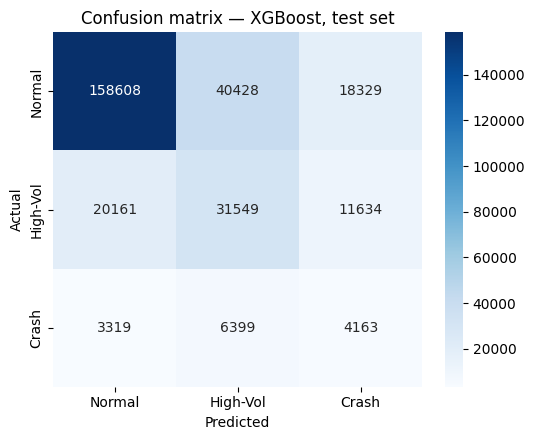


Crash-class PR-AUC : 0.1227
Macro PR-AUC       : 0.4885
ROC-AUC (OvR)      : 0.7628


In [ ]:
# ============================================================
# BLOCK 9 — FINAL MODEL: fit on full train, evaluate on 2019-2022 test set
# ============================================================
final_model = XGBClassifier(**final_params)
final_model.fit(X_train, y_train, sample_weight=sample_weight_full)

test_proba = final_model.predict_proba(X_test)
test_pred  = test_proba.argmax(axis=1)

print("=== Classification report (test set, 2019-2022) ===")
print(classification_report(y_test, test_pred, target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — XGBoost, test set")
plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc(y_test, test_proba):.4f}")
print(f"Macro PR-AUC       : {macro_pr_auc(y_test, test_proba):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test, test_proba, multi_class='ovr'):.4f}")

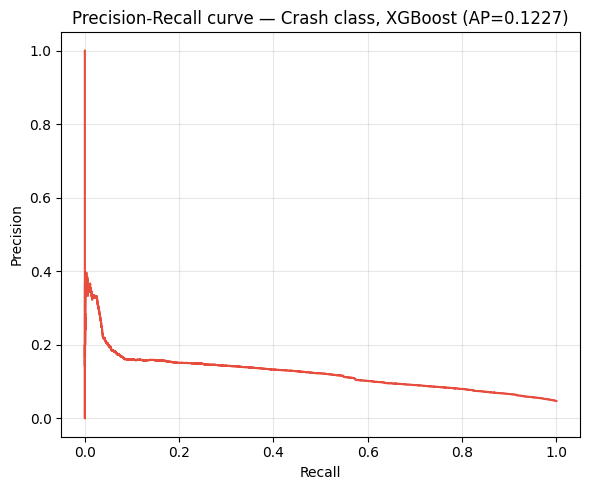

Recall @ FPR<=5%: 0.1832  (threshold=0.4069)
Precision@top-50 alerts: 0.2600
Precision@top-100 alerts: 0.3600
Precision@top-500 alerts: 0.3520
Precision@top-1000 alerts: 0.3290

Event-level crash recall (±1 day tolerance): 0.4691  (11471 distinct crash episodes)


In [ ]:
# ============================================================
# BLOCK 10 — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# ============================================================
prec, rec, thresh = precision_recall_curve(y_test == CRASH_IDX, test_proba[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, color="#e74c3c")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, XGBoost (AP={average_precision_score(y_test==CRASH_IDX, test_proba[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Recall at a fixed false-positive-rate budget (e.g. FPR <= 5%)
from sklearn.metrics import roc_curve
fpr, tpr, roc_thresh = roc_curve(y_test == CRASH_IDX, test_proba[:, CRASH_IDX])
target_fpr = 0.05
idx = np.searchsorted(fpr, target_fpr, side="right") - 1
idx = max(idx, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr[idx]:.4f}  (threshold={roc_thresh[idx]:.4f})")

# Precision among the model's top-K most confident crash alerts — the
# realistic "how good are your loudest alarms" operational metric.
for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba[:, CRASH_IDX])[:k]
    prec_at_k = (y_test[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

# Event-level detection: group consecutive per-stock crash rows into
# discrete "episodes" and check whether the model raised at least one
# alert within a +/-1 trading-day tolerance window of each episode —
# row-level recall alone over-penalizes multi-day crash streaks that are
# really one event (Reviewer 4's event-level ask).
def event_level_recall(test_df, y_test, test_pred, tolerance=1):
    tdf = test_df.copy()
    tdf["y_true"] = y_test
    tdf["y_pred"] = test_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        # identify contiguous crash episodes
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

ev_recall, n_events = event_level_recall(test_df, y_test, test_pred, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall:.4f}  ({n_events} distinct crash episodes)")

Brier score (crash)          : 0.10196
Brier score, prevalence-only baseline : 0.04490
Brier Skill Score vs. prevalence baseline: -1.2708  (0 = no better than base rate, 1 = perfect)
NOTE: a low raw Brier score is close to automatic under a ~5% base rate —
      the skill score above, not the raw Brier score, is what should be reported as evidence of calibration.


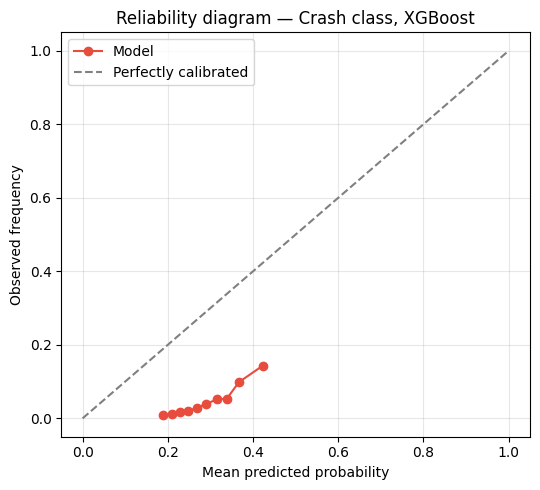


Expected Calibration Error (crash): 0.2400


In [ ]:
# ============================================================
# BLOCK 11 — CALIBRATION DIAGNOSTICS
# ============================================================
y_crash_true = (y_test == CRASH_IDX).astype(int)
p_crash = test_proba[:, CRASH_IDX]

brier = brier_score_loss(y_crash_true, p_crash)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash, prevalence))
brier_skill_score = 1 - (brier / brier_baseline)

print(f"Brier score (crash)          : {brier:.5f}")
print(f"Brier score, prevalence-only baseline : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline: {brier_skill_score:.4f}  "
      f"(0 = no better than base rate, 1 = perfect)")
print("NOTE: a low raw Brier score is close to automatic under a ~5% base rate —")
print("      the skill score above, not the raw Brier score, is what should be reported as evidence of calibration.")

frac_pos, mean_pred = calibration_curve(y_crash_true, p_crash, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred, frac_pos, marker="o", color="#e74c3c", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, XGBoost")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Expected Calibration Error
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(p_crash, bins) - 1
ece = 0.0
for b in range(10):
    mask = bin_ids == b
    if mask.sum() == 0: continue
    ece += (mask.sum() / len(p_crash)) * abs(y_crash_true[mask].mean() - p_crash[mask].mean())
print(f"\nExpected Calibration Error (crash): {ece:.4f}")

In [ ]:
# ============================================================
# BLOCK 12 — REGIME-SPECIFIC PERFORMANCE
# ============================================================
REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

test_df_eval = test_df.copy()
test_df_eval["y_true"] = y_test
test_df_eval["y_pred"] = test_pred
test_df_eval["p_crash"] = test_proba[:, CRASH_IDX]

regime_rows = []
for name, (start, end) in REGIMES.items():
    mask = (test_df_eval["date"] >= start) & (test_df_eval["date"] <= end)
    sub = test_df_eval[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df = pd.DataFrame(regime_rows).set_index("regime")
print(regime_df.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        88242      0.0523        0.2793           0.1362   
COVID crash              6099      0.2289        0.4577           0.2302   
Post-COVID recovery    123425      0.0472        0.2798           0.1018   
Russia-Ukraine (2022)   64780      0.0262        0.3151           0.1039   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.1437  
COVID crash                  0.2257  
Post-COVID recovery          0.1057  
Russia-Ukraine (2022)        0.0992  


PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test set)
                  feature  importance_mean  importance_std  label_adjacent
15               bb_width          0.04433         0.00064           False
5   rolling_5d_volatility          0.03075         0.00047           False
2     intraday_volatility          0.01039         0.00068            True
13                stoch_d          0.00926         0.00015           False
3       volume_change_pct          0.00605         0.00041           False
16                 atr_14          0.00359         0.00056           False
14                 roc_10          0.00163         0.00013           False
0            daily_return          0.00124         0.00016            True
6    rolling_10d_momentum          0.00072         0.00011           False
17                    obv          0.00061         0.00008           False
8                    macd          0.00023         0.00007           False
4               price_gap          0.0002

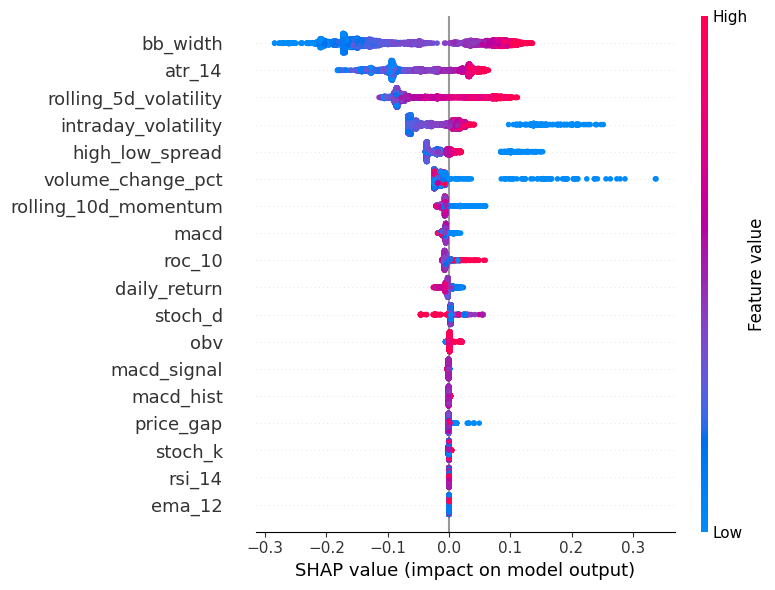


LABEL-ADJACENT FEATURE CONTRIBUTION CHECK
Full model crash PR-AUC                               : 0.1227
Excl. daily_return/intraday_volatility, crash PR-AUC  : 0.1168
(Interpret any importance/contribution above only as associational, not causal — Reviewer 4.)


In [ ]:
# ============================================================
# BLOCK 13 (fixed) — PERMUTATION IMPORTANCE + SHAP
# Reviewer 4 asked that daily_return / intraday_volatility be handled
# carefully in interpretation since they sit structurally close to the
# label-generating rule (even though used at t to predict t+1, not
# same-day). We report full-model importances but flag those two, AND
# run a companion model excluding them to quantify their marginal
# contribution — covering both the literal and the interpretive ask.
# ============================================================
LABEL_ADJACENT = ["daily_return", "intraday_volatility"]

# ------------------------------------------------------------
# Permutation importance (out-of-sample, on the held-out test set)
# ------------------------------------------------------------
perm = permutation_importance(final_model, X_test, y_test, scoring=crash_scorer,
                               n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
    "label_adjacent": [f in LABEL_ADJACENT for f in ALL_FEATURES]
}).sort_values("importance_mean", ascending=False)
print("="*70)
print("PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test set)")
print("="*70)
print(perm_df.round(5))

# ------------------------------------------------------------
# SHAP — handles both old (list-of-arrays) and new (3D-array) shap APIs
# ------------------------------------------------------------
explainer = shap.TreeExplainer(final_model)
shap_values_raw = explainer.shap_values(X_test[:5000])   # subsample for speed

if isinstance(shap_values_raw, list):
    # older shap: list of (n_samples, n_features) arrays, one per class
    shap_values_crash = shap_values_raw[CRASH_IDX]
else:
    # newer shap: single (n_samples, n_features, n_classes) array
    shap_values_crash = shap_values_raw[:, :, CRASH_IDX]

print("\nSHAP values shape (crash class):", shap_values_crash.shape)
print("Expected: (5000,", len(ALL_FEATURES), ")")

shap.summary_plot(shap_values_crash, X_test[:5000], feature_names=ALL_FEATURES,
                   show=True, plot_size=(8, 6))

# ------------------------------------------------------------
# Companion model excluding label-adjacent features — quantifies their
# marginal contribution to crash detection, framed as associational only.
# ------------------------------------------------------------
ALT_FEATURES = [f for f in ALL_FEATURES if f not in LABEL_ADJACENT]
X_train_alt = train_df[ALT_FEATURES].values
X_test_alt  = test_df[ALT_FEATURES].values

alt_model = XGBClassifier(**final_params)
alt_model.fit(X_train_alt, y_train, sample_weight=sample_weight_full)
alt_proba = alt_model.predict_proba(X_test_alt)

print("\n" + "="*70)
print("LABEL-ADJACENT FEATURE CONTRIBUTION CHECK")
print("="*70)
print(f"Full model crash PR-AUC                               : {crash_pr_auc(y_test, test_proba):.4f}")
print(f"Excl. daily_return/intraday_volatility, crash PR-AUC  : {crash_pr_auc(y_test, alt_proba):.4f}")
print("(Interpret any importance/contribution above only as associational, not causal — Reviewer 4.)")

In [ ]:
# ============================================================
# BLOCK 14 — SMOTE VARIANT: same CV, same scorer, for direct comparison
# ============================================================
smote_param_grid = {f"clf__{k}": [v] if not isinstance(v, list) else v
                     for k, v in {"max_depth": best_params.get("max_depth", 5),
                                  "learning_rate": best_params.get("learning_rate", 0.1),
                                  "n_estimators": best_params.get("n_estimators", 400)}.items()}

gs_smote = GridSearchCV(xgb_smote, smote_param_grid, scoring=crash_scorer,
                         cv=cv_splits, n_jobs=1, refit=True, verbose=1)
gs_smote.fit(X_train, y_train)

smote_test_proba = gs_smote.predict_proba(X_test)
print(f"\n[SMOTE variant]  crash PR-AUC (test): {crash_pr_auc(y_test, smote_test_proba):.4f}")
print(f"[Class-weight variant]  crash PR-AUC (test): {crash_pr_auc(y_test, test_proba):.4f}")

# Report resampling ratios / synthetic sample counts for the paper, per Reviewer 4
smote_step = gs_smote.best_estimator_.named_steps["smote"]
print("\nSMOTE resampling report:")
print("  random_state:", smote_step.random_state)
print("  Original class counts:", np.bincount(y_train))
print("  (Resampled counts happen internally per-fold during CV; for a single")
print("   illustrative fit on full train:)")
X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
print("  Resampled class counts (full-train illustration):", np.bincount(y_res))

Fitting 5 folds for each of 1 candidates, totalling 5 fits

[SMOTE variant]  crash PR-AUC (test): 0.1268
[Class-weight variant]  crash PR-AUC (test): 0.1227

SMOTE resampling report:
  random_state: 42
  Original class counts: [465423 129879  35054]
  (Resampled counts happen internally per-fold during CV; for a single
   illustrative fit on full train:)
  Resampled class counts (full-train illustration): [465423 465423 465423]


In [ ]:
# ============================================================
# BLOCK 15 — SUMMARY TABLE FOR THE PAPER
# ============================================================
summary = pd.DataFrame({
    "Model": ["Naive persistence", "Logistic regression", "XGBoost (class-weighted)", "XGBoost (SMOTE)"],
    "Crash PR-AUC": [
        average_precision_score(y_test==CRASH_IDX, (persist_pred==CRASH_IDX).astype(float)),
        average_precision_score(y_test==CRASH_IDX, logreg_proba[:, CRASH_IDX]),
        crash_pr_auc(y_test, test_proba),
        crash_pr_auc(y_test, smote_test_proba),
    ],
    "Crash Recall": [
        persist_crash_recall,
        recall_score(y_test==CRASH_IDX, logreg_pred==CRASH_IDX),
        recall_score(y_test==CRASH_IDX, test_pred==CRASH_IDX),
        recall_score(y_test==CRASH_IDX, smote_test_proba.argmax(axis=1)==CRASH_IDX),
    ],
})
print(summary.round(4))

                      Model  Crash PR-AUC  Crash Recall
0         Naive persistence        0.0691        0.1737
1       Logistic regression        0.1222        0.2532
2  XGBoost (class-weighted)        0.1227        0.2999
3           XGBoost (SMOTE)        0.1268        0.3204


1. CLASSIFICATION REPORT (test set, 2019-2022)
              precision  recall  f1-score      support
Normal           0.8711  0.7297    0.7941  217365.0000
High-Vol         0.4025  0.4981    0.4452   63344.0000
Crash            0.1220  0.2999    0.1734   13881.0000
accuracy         0.6596  0.6596    0.6596       0.6596
macro avg        0.4652  0.5092    0.4709  294590.0000
weighted avg     0.7350  0.6596    0.6899  294590.0000

2. CROSS-VALIDATION REPORT (mean ± std across folds)
              precision_mean  precision_std  recall_mean  recall_std  \
class_metric                                                           
Crash                 0.1456         0.0325       0.2772      0.0762   
High-Vol              0.3819         0.0320       0.4308      0.0156   
Normal                0.8469         0.0461       0.7596      0.0718   
accuracy              0.6719         0.0798       0.6719      0.0798   
macro avg             0.4581         0.0071       0.4892      0.0128   
weighted a

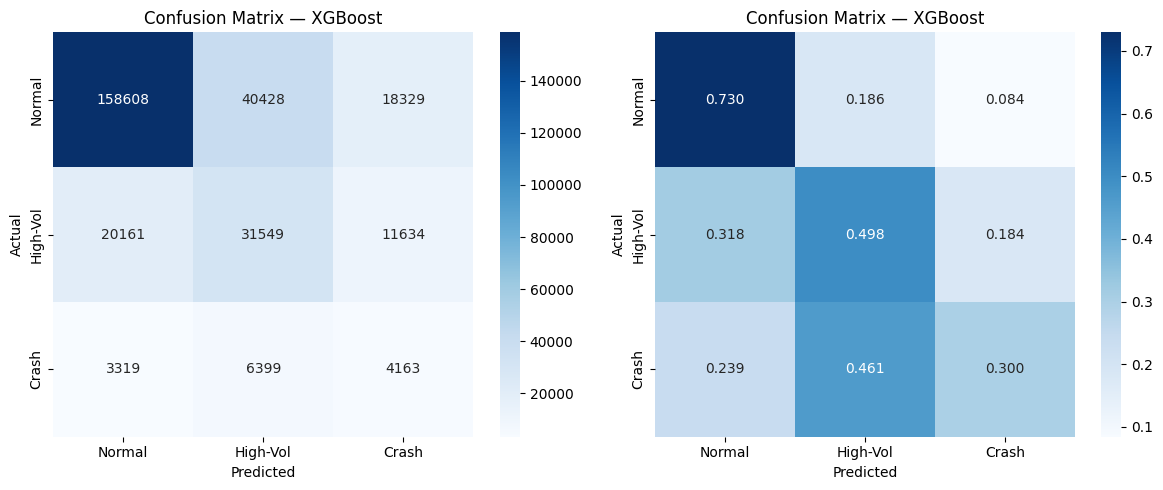

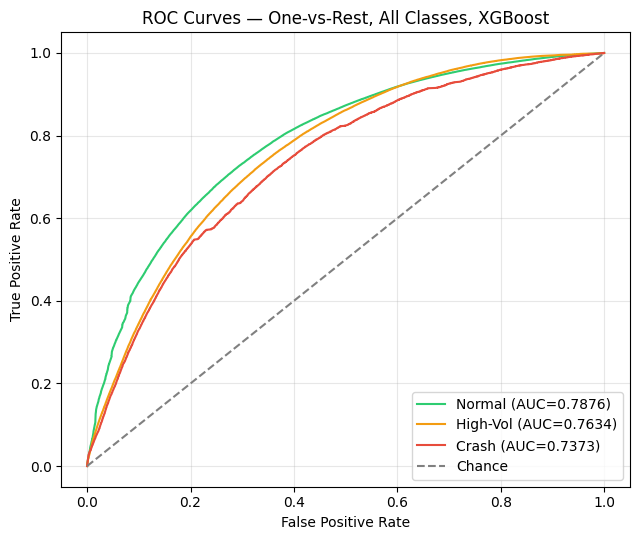


REPORT COMPLETE


In [ ]:
# ============================================================
# BLOCK 16 — FINAL COMPREHENSIVE REPORT
# Classification report, CV mean±std report, confusion matrices (raw +
# normalized), ROC curves (all classes, one-vs-rest) — final results
# package for the paper.
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

CLASS_ORDER = [0, 1, 2]
CLASS_LABELS_LIST = [CLASS_NAMES[c] for c in CLASS_ORDER]

# ------------------------------------------------------------
# 1. CLASSIFICATION REPORT — held-out test set
# ------------------------------------------------------------
print("="*70)
print("1. CLASSIFICATION REPORT (test set, 2019-2022)")
print("="*70)
report_dict = classification_report(y_test, test_pred, target_names=CLASS_LABELS_LIST,
                                     digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).T
print(report_df.round(4))

# ------------------------------------------------------------
# 2. CROSS-VALIDATION REPORT — mean ± std of the SAME metrics across folds
# Refits final_params on each fold's training slice (same folds as Block 8),
# computes full per-class classification_report per fold, then aggregates.
# ------------------------------------------------------------
print("\n" + "="*70)
print("2. CROSS-VALIDATION REPORT (mean ± std across folds)")
print("="*70)

per_fold_reports = []
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    model = XGBClassifier(**final_params)
    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])
    model.fit(X_train[tr_idx], y_train[tr_idx], sample_weight=fold_weights)

    va_pred = model.predict(X_train[va_idx])
    y_va = y_train[va_idx]

    rep = classification_report(y_va, va_pred, target_names=CLASS_LABELS_LIST,
                                 digits=4, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df["fold"] = i + 1
    per_fold_reports.append(rep_df)

all_folds_df = pd.concat(per_fold_reports)
all_folds_df.index.name = "class_metric"
all_folds_df = all_folds_df.reset_index()

cv_summary = all_folds_df.groupby("class_metric")[["precision", "recall", "f1-score", "support"]].agg(["mean", "std"])
cv_summary.columns = ["_".join(c) for c in cv_summary.columns]
print(cv_summary.round(4))

# accuracy is a single scalar per fold (stored under 'accuracy' row differently) — extract separately
fold_accuracies = [classification_report(y_train[va_idx],
                    XGBClassifier(**final_params).fit(
                        X_train[tr_idx], y_train[tr_idx],
                        sample_weight=compute_sample_weight("balanced", y_train[tr_idx])
                    ).predict(X_train[va_idx]),
                    output_dict=True, zero_division=0)["accuracy"]
                    for tr_idx, va_idx in cv_splits]
print(f"\nAccuracy across folds: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print("(Note: this refits the model 5 more times, ~5x Block 8's runtime — expect it to take a while.)")

# ------------------------------------------------------------
# 3. CONFUSION MATRIX — raw and normalized
# ------------------------------------------------------------
cm_raw = confusion_matrix(y_test, test_pred)
cm_norm = confusion_matrix(y_test, test_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[0])
axes[0].set_title("Confusion Matrix — XGBoost")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[1])
axes[1].set_title("Confusion Matrix — XGBoost")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. ROC CURVES — one-vs-rest, all classes
# ------------------------------------------------------------
y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)

plt.figure(figsize=(6.5, 5.5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{CLASS_NAMES[c]} (AUC={roc_auc_c:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest, All Classes, XGBoost")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("REPORT COMPLETE")
print("="*70)